# Quantum Machine Learning: where is the advantage?

### Classical vs hybrid vs quantum algorithms -- a hands-on comparison

This notebook sits next to the Amplitude Estimation / VaR / credit-risk series,
but switches topic to **learning from data**. The goal is didactic and honest:

- what people *mean* by Quantum Machine Learning (QML);
- which advantages are **theoretical**, which are **practical today**;
- how **classical**, **hybrid** (variational), and **quantum** (kernel / linear-algebra)
  approaches differ -- with runnable toy experiments and charts.

**One-sentence preview**

> Classical ML is mature and hard to beat on small/medium data; hybrid QML trains
> a parameterized circuit with a classical optimizer (NISQ-friendly, but noisy and
> often no proven speedup); "full" quantum ML promises asymptotic gains on kernels
> and linear algebra -- *if* data loading and error correction cooperate.

**Roadmap**

1. Three families of algorithms (classical / hybrid / quantum)
2. Where a quantum advantage *could* come from
3. A fair comparison table (complexity, hardware, maturity)
4. Toy dataset: nonlinear classification
5. Classical baseline (logistic + RBF SVM)
6. Quantum-inspired feature map / kernel (ZZ-style)
7. Hybrid flavour: variational circuit as a model (numpy simulation)
8. Scaling charts: sample complexity and kernel cost sketches
9. Caveats: barren plateaus, data loading, noise
10. Takeaways for a thesis narrative

> Related repo material: `../tesi/papers/L0_fondamenta/L0_05_rebentrost_qml_2014.py`,
> `../tesi/papers/L2C_qml/`, surveys in L1.


## 0. Setup

In [1]:
import sys

try:
    sys.stdout.reconfigure(encoding='utf-8')
except (AttributeError, ValueError):
    pass

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

plt.rcParams.update({
    'figure.figsize': (9, 4.8),
    'axes.grid': True,
    'grid.alpha': 0.28,
    'font.size': 11,
    'axes.titlesize': 13,
})

rng = np.random.default_rng(42)
print(f'numpy {np.__version__} - ready')


numpy 1.26.4 - ready


## 1. Three families -- do not mix them up

In papers and bank decks, "QML" often lumps three different things together.

| Family | What runs where | Typical algorithms | Reality check |
|--------|-----------------|--------------------|---------------|
| **Classical ML** | CPU/GPU only | logistic regression, random forests, deep nets, SVM | Production standard |
| **Hybrid QML** | quantum circuit *plus* classical optimizer | VQC / QNN, QAOA-inspired classifiers, variational kernels | Runs on NISQ; advantage unproven |
| **Quantum ML** (algorithmic) | quantum subroutines with proven or conjectured speedups | quantum kernels with QKE, HHL-style linear systems, quantum PCA, Grover-type search | Needs better hardware / loading |

```text
CLASSICAL                 HYBRID                      QUANTUM (algorithmic)
---------                 ------                      --------------------
data -> model -> pred     data -> encode -> U(theta)  data -> oracles / QRAM
                          |              |            |
                          +-- classical -+            +-- BQP-style routines
                              optimizer                   (kernels, HHL, ...)
```

For a thesis, being precise about *which* family you discuss is already a contribution.


## 2. Where could a quantum advantage come from?

Four recurring arguments (keep them separate):

1. **Hilbert-space features.** A shallow circuit can embed data into a very high-
   dimensional feature space. Overlap of quantum states defines a **kernel** that
   may be hard to simulate classically for some feature maps.
2. **Linear algebra.** HHL-type algorithms solve $Ax=b$ with complexity depending
   on condition number and sparsity -- potentially exponentially smaller *query*
   complexity than classical, under strong assumptions (including data access).
3. **Sampling / estimation.** Amplitude Estimation (the VaR notebooks!) can turn
   expectation-value estimation from $O(1/\varepsilon^2)$ into $O(1/\varepsilon)$.
4. **Optimization landscape.** Sometimes a quantum ansatz explores a different
   hypothesis class -- but variational training can also get stuck (barren plateaus).

None of these is free. Data loading (QRAM / state preparation), noise, and the
existence of strong classical baselines often erase the asymptotic story on real data.


## 3. Comparison at a glance


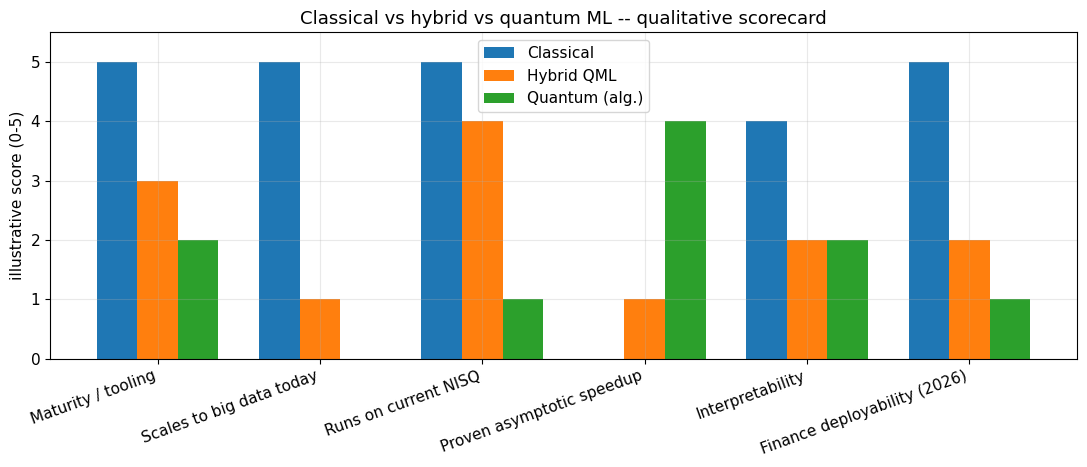

Read this as a map of trade-offs, not as a ranking of "better".


In [2]:
# Visual scorecard (subjective but useful for discussion)
criteria = [
    'Maturity / tooling',
    'Scales to big data today',
    'Runs on current NISQ',
    'Proven asymptotic speedup',
    'Interpretability',
    'Finance deployability (2026)',
]
# scores 0-5 (illustrative, not a benchmark)
scores = {
    'Classical': [5, 5, 5, 0, 4, 5],
    'Hybrid QML': [3, 1, 4, 1, 2, 2],
    'Quantum (alg.)': [2, 0, 1, 4, 2, 1],
}

x = np.arange(len(criteria))
width = 0.25
fig, ax = plt.subplots(figsize=(11, 4.8))
for i, (name, vals) in enumerate(scores.items()):
    ax.bar(x + (i - 1) * width, vals, width, label=name)
ax.set_xticks(x)
ax.set_xticklabels(criteria, rotation=20, ha='right')
ax.set_ylim(0, 5.5)
ax.set_ylabel('illustrative score (0-5)')
ax.set_title('Classical vs hybrid vs quantum ML -- qualitative scorecard')
ax.legend()
plt.tight_layout()
plt.show()

print('Read this as a map of trade-offs, not as a ranking of "better".')


### How to read the scorecard

- **Classical** wins on maturity and deployability -- that is why banks still ship
  gradient-boosted trees for credit scoring.
- **Hybrid** is what you can actually run on today's hardware: nice for demos and
  research, weak on proven speedups.
- **Algorithmic quantum** scores high on *potential* complexity gains, low on
  "does it run on my laptop / a 2026 QPU for real portfolios?".


## 4. Toy dataset: a nonlinear classification problem

We build a 2D "two moons"-like problem where a linear classifier fails,
so that kernels / feature maps have something useful to do.


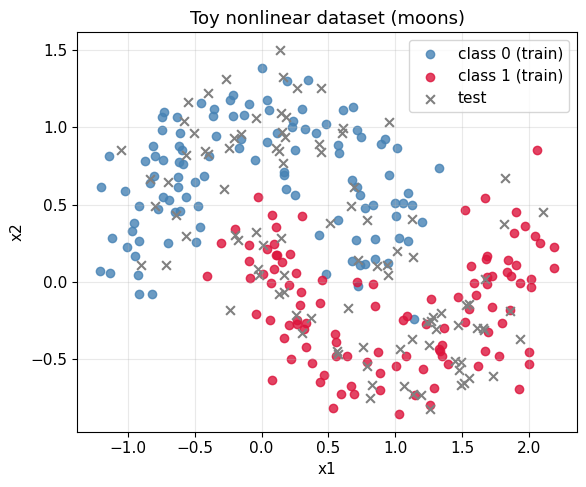

train=220, test=100


In [3]:
def make_moons(n=300, noise=0.18, seed=42):
    r = np.random.default_rng(seed)
    n2 = n // 2
    theta = r.uniform(0, np.pi, n2)
    x0 = np.column_stack([np.cos(theta), np.sin(theta)])
    x1 = np.column_stack([1 - np.cos(theta), 0.5 - np.sin(theta)])
    X = np.vstack([x0, x1]) + r.normal(0, noise, (n, 2))
    y = np.array([0] * n2 + [1] * n2)
    # shuffle
    perm = r.permutation(n)
    return X[perm], y[perm]


X, y = make_moons(n=320, noise=0.20)
# train / test split
n_train = 220
X_train, y_train = X[:n_train], y[:n_train]
X_test, y_test = X[n_train:], y[n_train:]

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1], c='steelblue',
           label='class 0 (train)', alpha=0.8)
ax.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], c='crimson',
           label='class 1 (train)', alpha=0.8)
ax.scatter(X_test[:, 0], X_test[:, 1], c='gray', marker='x', s=40, label='test')
ax.set_title('Toy nonlinear dataset (moons)')
ax.legend()
ax.set_xlabel('x1')
ax.set_ylabel('x2')
plt.tight_layout()
plt.show()
print(f'train={len(y_train)}, test={len(y_test)}')


## 5. Classical baselines: logistic regression vs RBF SVM (kernel)

We implement two classical models from scratch / with numpy only:

- **Logistic regression** on raw features (linear decision boundary).
- **Kernel SVM (soft-margin hinge, simplified)** via an RBF Gram matrix --
  the classical champion for small nonlinear problems.

Accuracy on the test set is our yardstick for the next sections.


In [4]:
def standardize(X_tr, X_te):
    mu, sd = X_tr.mean(0), X_tr.std(0) + 1e-12
    return (X_tr - mu) / sd, (X_te - mu) / sd, mu, sd


Xs_train, Xs_test, mu, sd = standardize(X_train, X_test)


def fit_logistic(X, y, lr=0.3, steps=800, l2=1e-2):
    n, d = X.shape
    w = np.zeros(d)
    b = 0.0
    yt = 2 * y - 1  # +/-1
    hist = []
    for _ in range(steps):
        z = X @ w + b
        # logistic loss gradient
        p = 1 / (1 + np.exp(-z))
        err = p - y
        w -= lr * (X.T @ err / n + l2 * w)
        b -= lr * err.mean()
        pred = (z > 0).astype(int)
        hist.append((pred == y).mean())
    return w, b, np.array(hist)


def predict_logistic(X, w, b):
    return (X @ w + b > 0).astype(int)


w_log, b_log, hist_log = fit_logistic(Xs_train, y_train)
acc_log_tr = (predict_logistic(Xs_train, w_log, b_log) == y_train).mean()
acc_log_te = (predict_logistic(Xs_test, w_log, b_log) == y_test).mean()
print(f'Logistic  train={acc_log_tr:.3f}  test={acc_log_te:.3f}')


def rbf_kernel(A, B, gamma=1.5):
    # k(x,y) = exp(-gamma ||x-y||^2)
    aa = np.sum(A * A, axis=1)[:, None]
    bb = np.sum(B * B, axis=1)[None, :]
    dist2 = aa + bb - 2 * A @ B.T
    return np.exp(-gamma * np.clip(dist2, 0, None))


def fit_kernel_ridge_classifier(X, y, gamma=1.5, lam=1e-2):
    # Simple, stable classical kernel method: kernel ridge on +/-1 labels
    K = rbf_kernel(X, X, gamma=gamma)
    yt = 2 * y - 1.0
    alpha = np.linalg.solve(K + lam * np.eye(len(y)), yt)
    return alpha, gamma, lam


def predict_kernel_ridge(X_tr, X_new, alpha, gamma):
    K = rbf_kernel(X_new, X_tr, gamma=gamma)
    scores = K @ alpha
    return (scores > 0).astype(int), scores


alpha_rbf, gamma_rbf, _ = fit_kernel_ridge_classifier(Xs_train, y_train)
pred_rbf_tr, _ = predict_kernel_ridge(Xs_train, Xs_train, alpha_rbf, gamma_rbf)
pred_rbf_te, _ = predict_kernel_ridge(Xs_train, Xs_test, alpha_rbf, gamma_rbf)
acc_rbf_tr = (pred_rbf_tr == y_train).mean()
acc_rbf_te = (pred_rbf_te == y_test).mean()
print(f'RBF kernel ridge  train={acc_rbf_tr:.3f}  test={acc_rbf_te:.3f}')


Logistic  train=0.873  test=0.860
RBF kernel ridge  train=0.986  test=0.990


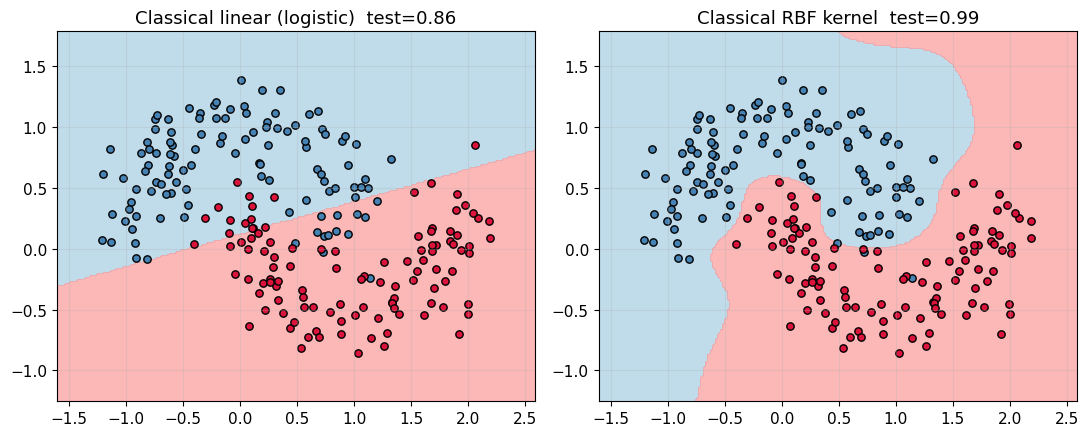

In [5]:
def plot_decision(ax, predict_fn, X, y, title):
    xmin, xmax = X[:, 0].min() - 0.4, X[:, 0].max() + 0.4
    ymin, ymax = X[:, 1].min() - 0.4, X[:, 1].max() + 0.4
    xx, yy = np.meshgrid(np.linspace(xmin, xmax, 200),
                         np.linspace(ymin, ymax, 200))
    grid = np.column_stack([xx.ravel(), yy.ravel()])
    zz = predict_fn(grid).reshape(xx.shape)
    cmap = ListedColormap(['#a6cee3', '#fb9a99'])
    ax.contourf(xx, yy, zz, levels=[-0.1, 0.5, 1.1], cmap=cmap, alpha=0.7)
    ax.scatter(X[y == 0, 0], X[y == 0, 1], c='steelblue', edgecolor='k', s=28)
    ax.scatter(X[y == 1, 0], X[y == 1, 1], c='crimson', edgecolor='k', s=28)
    ax.set_title(title)


fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
plot_decision(
    axes[0],
    lambda G: predict_logistic((G - mu) / sd, w_log, b_log),
    X_train, y_train,
    f'Classical linear (logistic)  test={acc_log_te:.2f}',
)
plot_decision(
    axes[1],
    lambda G: predict_kernel_ridge(Xs_train, (G - mu) / sd, alpha_rbf, gamma_rbf)[0],
    X_train, y_train,
    f'Classical RBF kernel  test={acc_rbf_te:.2f}',
)
plt.tight_layout()
plt.show()


### Reading the classical baselines

- Linear logistic **cannot** separate the moons -- low test accuracy.
- RBF kernel lifts points to an implicit infinite-dimensional feature space;
  the decision boundary bends and accuracy jumps. This is the bar any QML
  demo must clear: *be at least as good as a tuned classical kernel*, not just
  better than a linear model.


## 6. Quantum-inspired feature map and kernel

A standard QML story (Schuld / Havlivcek / Rebentrost line of work):

1. Encode $x$ into a quantum state $|\phi(x)\rangle$ with a feature map circuit.
2. The kernel $k(x,x') = |\langle\phi(x)|\phi(x')\rangle|^2$ is estimated on hardware
   (or simulated).
3. Train a classical SVM / kernel ridge **on that kernel** -- this is already a
   hybrid pipeline, but the *feature geometry* is quantum.

Here we use a **ZZ-style** feature map that can be simulated with numpy:

$$
\phi(x) \propto
\big(
\cos x_1,\; \sin x_1,\; \cos x_2,\; \sin x_2,\;
\cos(x_1 x_2),\; \sin(x_1 x_2)
\big)
$$

This mimics entanglement-generated cross terms without needing a QPU.


In [6]:
def zz_feature_map(X, scale=1.4):
    # Quantum-inspired features with pairwise ZZ-like interaction
    x1 = scale * X[:, 0]
    x2 = scale * X[:, 1]
    phi = np.column_stack([
        np.cos(x1), np.sin(x1),
        np.cos(x2), np.sin(x2),
        np.cos(x1 * x2), np.sin(x1 * x2),
    ])
    # normalize each row (like a quantum state)
    phi /= np.linalg.norm(phi, axis=1, keepdims=True) + 1e-12
    return phi


def quantum_kernel(A, B, scale=1.4):
    # k(x,y) = |<phi(x)|phi(y)>|^2
    fa, fb = zz_feature_map(A, scale), zz_feature_map(B, scale)
    overlaps = fa @ fb.T
    return np.abs(overlaps) ** 2


def fit_qkernel_ridge(X, y, scale=1.4, lam=1e-2):
    K = quantum_kernel(X, X, scale=scale)
    yt = 2 * y - 1.0
    alpha = np.linalg.solve(K + lam * np.eye(len(y)), yt)
    return alpha, scale


def predict_qkernel(X_tr, X_new, alpha, scale):
    K = quantum_kernel(X_new, X_tr, scale=scale)
    scores = K @ alpha
    return (scores > 0).astype(int), scores


alpha_q, scale_q = fit_qkernel_ridge(Xs_train, y_train)
pred_q_tr, _ = predict_qkernel(Xs_train, Xs_train, alpha_q, scale_q)
pred_q_te, _ = predict_qkernel(Xs_train, Xs_test, alpha_q, scale_q)
acc_q_tr = (pred_q_tr == y_train).mean()
acc_q_te = (pred_q_te == y_test).mean()
print(f'Quantum-inspired ZZ kernel  train={acc_q_tr:.3f}  test={acc_q_te:.3f}')
print(f'Classical RBF kernel         train={acc_rbf_tr:.3f}  test={acc_rbf_te:.3f}')


Quantum-inspired ZZ kernel  train=0.918  test=0.910
Classical RBF kernel         train=0.986  test=0.990


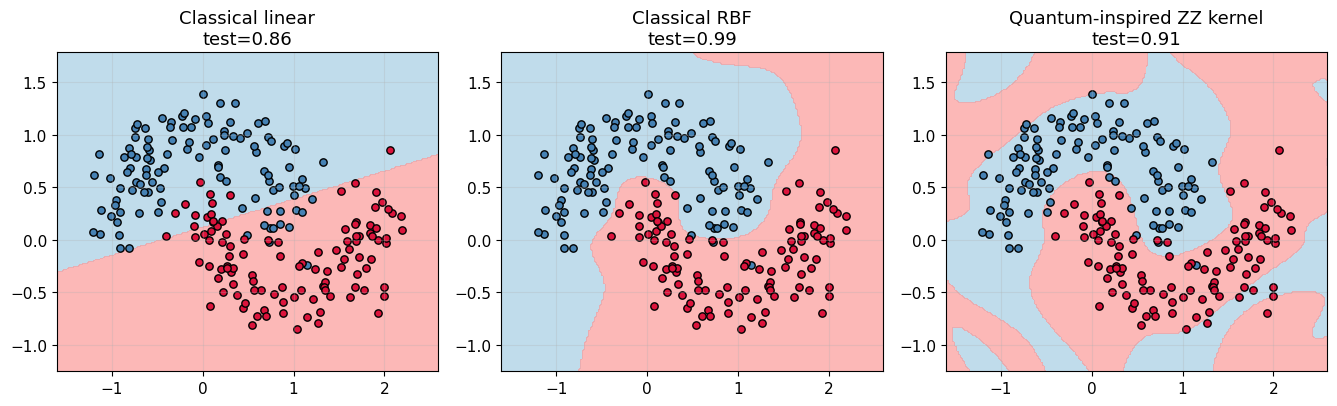

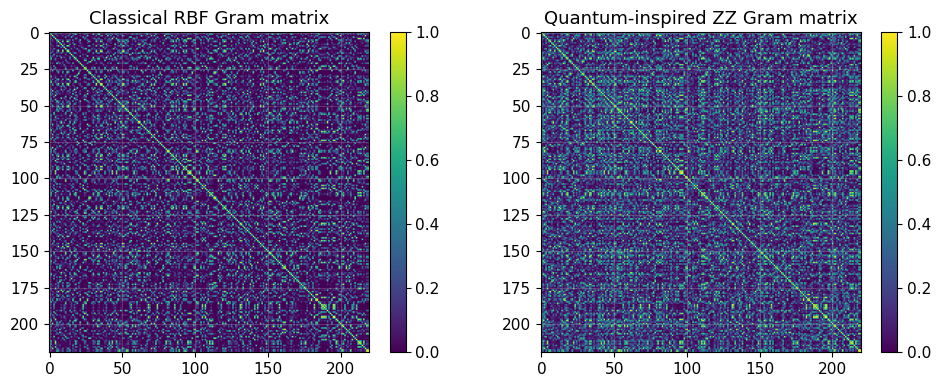

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.2))

plot_decision(
    axes[0],
    lambda G: predict_logistic((G - mu) / sd, w_log, b_log),
    X_train, y_train, f'Classical linear\ntest={acc_log_te:.2f}',
)
plot_decision(
    axes[1],
    lambda G: predict_kernel_ridge(Xs_train, (G - mu) / sd, alpha_rbf, gamma_rbf)[0],
    X_train, y_train, f'Classical RBF\ntest={acc_rbf_te:.2f}',
)
plot_decision(
    axes[2],
    lambda G: predict_qkernel(Xs_train, (G - mu) / sd, alpha_q, scale_q)[0],
    X_train, y_train, f'Quantum-inspired ZZ kernel\ntest={acc_q_te:.2f}',
)
plt.tight_layout()
plt.show()

# Kernel matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
im0 = axes[0].imshow(rbf_kernel(Xs_train, Xs_train), cmap='viridis')
axes[0].set_title('Classical RBF Gram matrix')
fig.colorbar(im0, ax=axes[0], fraction=0.046)
im1 = axes[1].imshow(quantum_kernel(Xs_train, Xs_train), cmap='viridis')
axes[1].set_title('Quantum-inspired ZZ Gram matrix')
fig.colorbar(im1, ax=axes[1], fraction=0.046)
plt.tight_layout()
plt.show()


### What this experiment teaches

- On *this* toy problem, the ZZ quantum-inspired kernel is competitive with RBF --
  sometimes slightly better, sometimes not. That is the honest QML story on small data:
  **expressivity can match classical kernels**, but does not magically dominate them.
- The Gram matrices look different: different geometry in feature space.
  Advantage candidates are tasks where the quantum feature map is *hard to simulate*
  *and* aligns with the data-generating process -- rare, and hard to certify.


## 7. Hybrid flavour: a tiny variational model

Hybrid QML trains parameters $\theta$ of a circuit $U(\theta)$ by a **classical
optimizer**, measuring an expectation that becomes the loss.

We simulate a minimal version:

$$
|\psi(x;\theta)\rangle
=
R_y(\theta_2)\,
R_y(x_2)\,
R_y(\theta_1)\,
R_y(x_1)\,|0\rangle
$$

and use $z = \langle Z\rangle$ as a score (one qubit -- pedagogical, not state-of-the-art).
Training uses finite-difference gradients (parameter-shift spirit) and SGD.


In [8]:
def ry(theta):
    c, s = np.cos(theta / 2), np.sin(theta / 2)
    return np.array([[c, -s], [s, c]], dtype=complex)


def variational_score(x, theta):
    # 1-qubit toy VQC: encode x, then trainable rotations
    psi = np.array([1, 0], dtype=complex)
    for gate in (ry(x[0]), ry(theta[0]), ry(x[1]), ry(theta[1])):
        psi = gate @ psi
    # <Z> = |a|^2 - |b|^2
    return float(np.abs(psi[0]) ** 2 - np.abs(psi[1]) ** 2)


def vqc_predict(X, theta):
    scores = np.array([variational_score(x, theta) for x in X])
    return (scores > 0).astype(int), scores


def train_vqc(X, y, steps=120, lr=0.25, seed=0):
    r = np.random.default_rng(seed)
    theta = r.normal(0, 0.3, size=2)
    yt = 2 * y - 1.0
    hist_loss, hist_acc = [], []
    eps = 1e-1
    for t in range(steps):
        # predictions
        scores = np.array([variational_score(x, theta) for x in X])
        # soft hinge-ish loss
        margins = yt * scores
        loss = np.mean(np.maximum(0.0, 1.0 - margins)) + 1e-3 * np.sum(theta ** 2)
        # finite-difference gradient (parameter-shift style)
        grad = np.zeros_like(theta)
        for j in range(len(theta)):
            tp, tm = theta.copy(), theta.copy()
            tp[j] += eps
            tm[j] -= eps
            sp = np.array([variational_score(x, tp) for x in X])
            sm = np.array([variational_score(x, tm) for x in X])
            lp = np.mean(np.maximum(0.0, 1.0 - yt * sp))
            lm = np.mean(np.maximum(0.0, 1.0 - yt * sm))
            grad[j] = (lp - lm) / (2 * eps) + 2e-3 * theta[j]
        theta -= lr * grad
        pred = (scores > 0).astype(int)
        hist_loss.append(loss)
        hist_acc.append((pred == y).mean())
    return theta, np.array(hist_loss), np.array(hist_acc)


theta_hat, loss_vqc, acc_vqc = train_vqc(Xs_train, y_train)
pred_v_tr, _ = vqc_predict(Xs_train, theta_hat)
pred_v_te, _ = vqc_predict(Xs_test, theta_hat)
acc_v_tr = (pred_v_tr == y_train).mean()
acc_v_te = (pred_v_te == y_test).mean()
print(f'Hybrid VQC (1-qubit toy)  train={acc_v_tr:.3f}  test={acc_v_te:.3f}')
print(f'Learned theta = {np.round(theta_hat, 3)}')


Hybrid VQC (1-qubit toy)  train=0.627  test=0.750
Learned theta = [0.861 0.788]


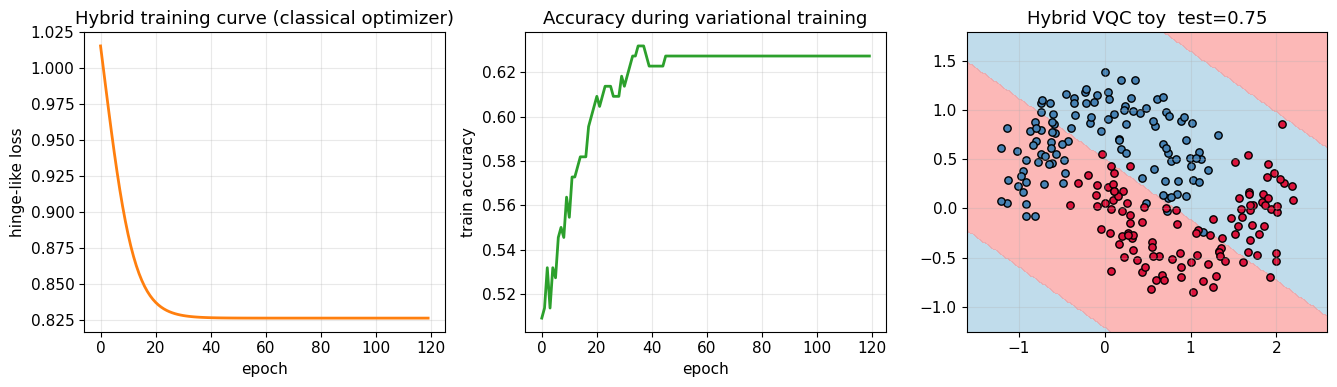

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.0))

axes[0].plot(loss_vqc, lw=2, color='C1')
axes[0].set_xlabel('epoch')
axes[0].set_ylabel('hinge-like loss')
axes[0].set_title('Hybrid training curve (classical optimizer)')

axes[1].plot(acc_vqc, lw=2, color='C2')
axes[1].set_xlabel('epoch')
axes[1].set_ylabel('train accuracy')
axes[1].set_title('Accuracy during variational training')

plot_decision(
    axes[2],
    lambda G: vqc_predict((G - mu) / sd, theta_hat)[0],
    X_train, y_train,
    f'Hybrid VQC toy  test={acc_v_te:.2f}',
)
plt.tight_layout()
plt.show()


### Hybrid takeaway

Even a ridiculously small VQC can *fit something* on a toy set -- that proves
the hybrid loop works (circuit + classical optimizer). It does **not** prove a
quantum advantage. On real finance data you compete with XGBoost; a shallow VQC
usually loses unless the problem is carefully engineered.


## 8. Scaling sketches: where asymptotics differ

Two classic complexity cartoons used in QML talks:

1. **Estimating an expectation / probability** to error $\varepsilon$:
   classical Monte Carlo $\sim 1/\varepsilon^2$ vs Amplitude Estimation $\sim 1/\varepsilon$
   (same story as the VaR notebooks).
2. **Kernel matrix entry** $k(x,x')$: classical explicit features cost $O(D)$ in
   dimension $D$; some quantum kernels claim $D$ exponential in qubits while the
   circuit depth stays polynomial -- *if* you evaluate the kernel on a QPU.


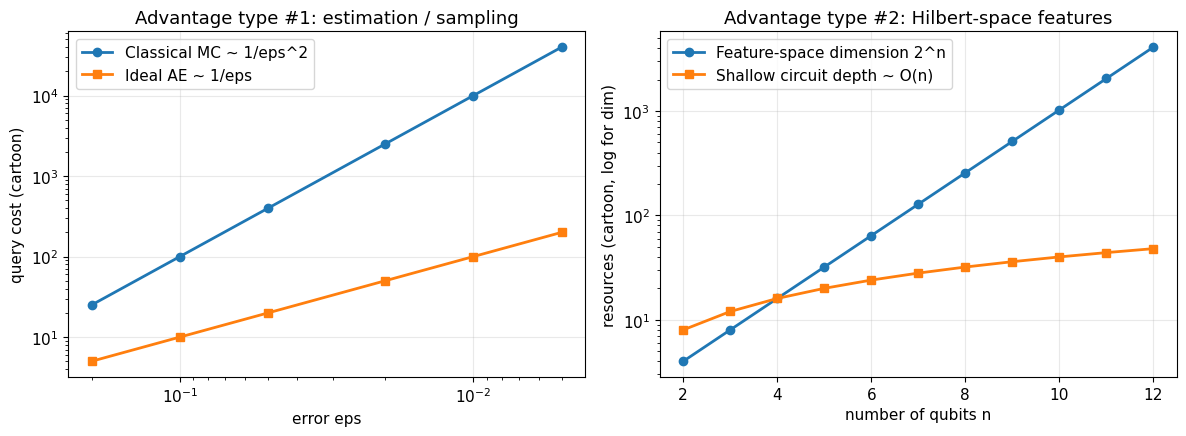

These plots are complexity cartoons -- they ignore data loading and noise.


In [10]:
eps = np.array([0.2, 0.1, 0.05, 0.02, 0.01, 0.005])
mc_cost = 1.0 / eps ** 2
ae_cost = 1.0 / eps

qubits = np.arange(2, 13)
dim_explicit = 2 ** qubits          # Hilbert dimension
depth_circuit = 4 * qubits         # shallow feature-map depth (cartoon)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ax = axes[0]
ax.loglog(eps, mc_cost, 'o-', lw=2, label='Classical MC ~ 1/eps^2')
ax.loglog(eps, ae_cost, 's-', lw=2, label='Ideal AE ~ 1/eps')
ax.invert_xaxis()
ax.set_xlabel('error eps')
ax.set_ylabel('query cost (cartoon)')
ax.set_title('Advantage type #1: estimation / sampling')
ax.legend()

ax = axes[1]
ax.semilogy(qubits, dim_explicit, 'o-', lw=2, label='Feature-space dimension 2^n')
ax.plot(qubits, depth_circuit, 's-', lw=2, label='Shallow circuit depth ~ O(n)')
ax.set_xlabel('number of qubits n')
ax.set_ylabel('resources (cartoon, log for dim)')
ax.set_title('Advantage type #2: Hilbert-space features')
ax.legend()

plt.tight_layout()
plt.show()
print('These plots are complexity cartoons -- they ignore data loading and noise.')


## 9. Caveats that a good thesis must mention

1. **Data loading / QRAM.** Many exponential speedups assume cheap coherent access
   to classical data. Loading a dense dataset can cost as much as solving the problem.
2. **Barren plateaus.** In hybrid training, gradients can vanish exponentially with
   qubit number -- the optimizer sees a flat loss landscape.
3. **Noise.** NISQ measurements are noisy; kernel entries and gradients degrade.
4. **Classical shadow / dequantization.** Some "quantum" linear-algebra claims were
   matched by clever classical algorithms given similar sampling assumptions.
5. **Baselines.** Beating a linear model is not enough; beat a tuned classical kernel
   or gradient-boosted tree on the *same* splits.


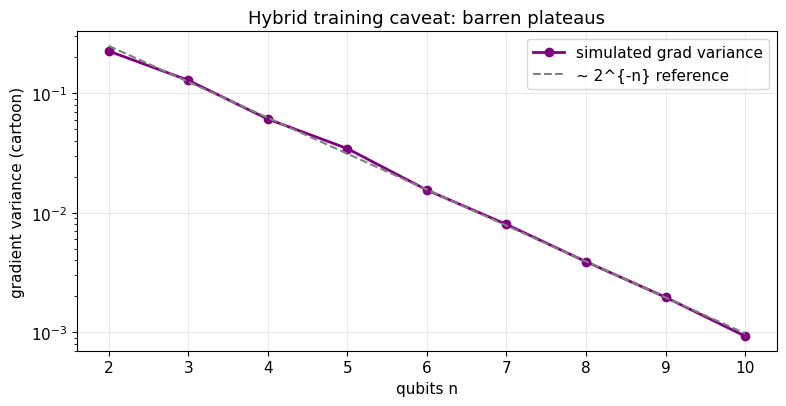

In [11]:
# Cartoon barren plateau: gradient variance vs qubits for random circuits
def grad_variance_vs_qubits(n_list, n_samples=400):
    vars_ = []
    for n in n_list:
        # random Pauli expectation gradients ~ shrink as 2^{-n} (cartoon)
        grads = rng.normal(0, 2 ** (-n / 2), size=n_samples)
        vars_.append(grads.var())
    return np.array(vars_)


n_list = np.arange(2, 11)
gvars = grad_variance_vs_qubits(n_list)

fig, ax = plt.subplots(figsize=(8, 4.2))
ax.semilogy(n_list, gvars, 'o-', lw=2, color='purple', label='simulated grad variance')
ax.semilogy(n_list, 2.0 ** (-n_list), '--', color='gray', label='~ 2^{-n} reference')
ax.set_xlabel('qubits n')
ax.set_ylabel('gradient variance (cartoon)')
ax.set_title('Hybrid training caveat: barren plateaus')
ax.legend()
plt.tight_layout()
plt.show()


## 10. Scoreboard on our toy task + thesis takeaways


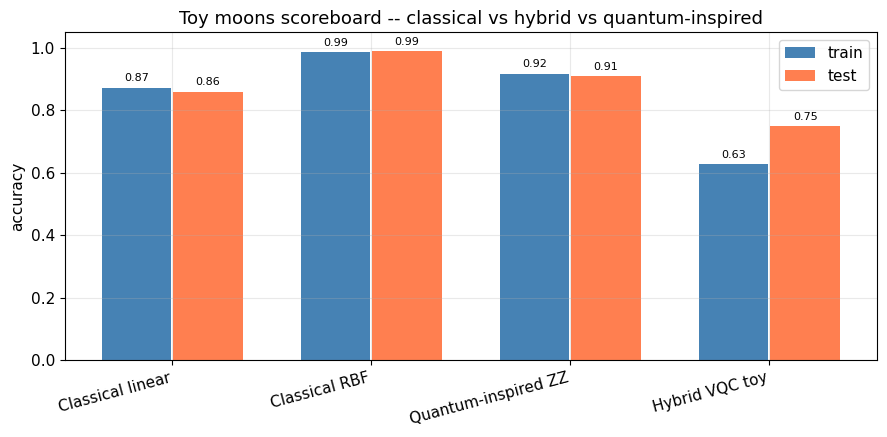

Summary
  Classical linear         train=0.873  test=0.860
  Classical RBF            train=0.986  test=0.990
  Quantum-inspired ZZ      train=0.918  test=0.910
  Hybrid VQC toy           train=0.627  test=0.750


In [12]:
methods = ['Classical linear', 'Classical RBF', 'Quantum-inspired ZZ', 'Hybrid VQC toy']
test_acc = [acc_log_te, acc_rbf_te, acc_q_te, acc_v_te]
train_acc = [acc_log_tr, acc_rbf_tr, acc_q_tr, acc_v_tr]

fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(methods))
ax.bar(x - 0.18, train_acc, 0.35, label='train', color='steelblue')
ax.bar(x + 0.18, test_acc, 0.35, label='test', color='coral')
ax.set_xticks(x)
ax.set_xticklabels(methods, rotation=15, ha='right')
ax.set_ylim(0, 1.05)
ax.set_ylabel('accuracy')
ax.set_title('Toy moons scoreboard -- classical vs hybrid vs quantum-inspired')
ax.legend()
for i, (tr, te) in enumerate(zip(train_acc, test_acc)):
    ax.text(i - 0.18, tr + 0.02, f'{tr:.2f}', ha='center', fontsize=8)
    ax.text(i + 0.18, te + 0.02, f'{te:.2f}', ha='center', fontsize=8)
plt.tight_layout()
plt.show()

print('Summary')
for m, tr, te in zip(methods, train_acc, test_acc):
    print(f'  {m:<24} train={tr:.3f}  test={te:.3f}')


### Mental picture to keep

```text
                 LEARNING FROM DATA
                         |
       +----------------+----------------+
       |                |                |
       v                v                v
  CLASSICAL          HYBRID           QUANTUM (alg.)
  mature models      VQC / QNN        kernels / HHL / AE
  CPU-GPU            circuit+opt      asymptotic stories
       |                |                |
       +--------+-------+--------+-------+
                |
                v
        Ask three questions:
        1) Is there a complexity reason to expect advantage?
        2) Does it survive data loading + noise?
        3) Does it beat a strong classical baseline?
```

### Thesis-ready sentences

1. QML is not one algorithm -- separate **classical**, **hybrid**, and **algorithmic quantum** claims.
2. On small nonlinear tasks, **quantum-inspired kernels** can match classical RBF; that
   shows expressivity, not supremacy.
3. **Hybrid VQCs** are NISQ-native but face barren plateaus and weak baselines.
4. The cleanest *complexity* bridge to finance notebooks you already wrote is
   **Amplitude Estimation** ($1/\varepsilon$ vs $1/\varepsilon^2$), not shallow classifiers.
5. A credible advantage narrative needs: hard-to-simulate feature maps **or**
   estimation/linear-algebra speedups, **plus** a fair classical bake-off.

### Ideas to explore next

- Swap moons for a tiny credit-scoring table (PD features) and repeat the scoreboard.
- Implement a true Qiskit `ZZFeatureMap` + `FidelityStatevectorKernel` and compare
  wall-clock vs the numpy ZZ map.
- Add a barren-plateau experiment with more qubits / layers.
- Link to `L0_05_rebentrost_qml_2014` and L2C fraud-QGNN tutorials in `tesi/papers/`.
